In [3]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Re-fetch TSLA data (same as our local data_loader.py logic)
raw = yf.download("TSLA", start="2015-01-01", end="2026-06-30", auto_adjust=True)
tsla = raw.copy()
tsla.columns = tsla.columns.get_level_values(0) if isinstance(tsla.columns, pd.MultiIndex) else tsla.columns

# Same chronological split as before
split_date = "2025-01-01"
train = tsla[tsla.index < split_date]
test = tsla[tsla.index >= split_date]

print(f"Train: {train.shape}, Test: {test.shape}")

[*********************100%***********************]  1 of 1 completed

Train: (2516, 5), Test: (372, 5)


In [4]:
from sklearn.preprocessing import MinMaxScaler

WINDOW_SIZE = 60  # use last 60 days to predict the next day, per task instructions

# Scale the training data to 0-1 range (fit ONLY on training data, to avoid leakage)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[["Close"]])

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2456, 60)
y_train shape: (2456,)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape to (samples, timesteps, features)
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
print(f"Reshaped X_train: {X_train_reshaped.shape}")

# Build the model
model_lstm = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model_lstm.compile(optimizer="adam", loss="mean_squared_error")
model_lstm.summary()

Reshaped X_train: (2456, 60, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model_lstm.fit(
    X_train_reshaped, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.0085 - val_loss: 0.0031
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0018 - val_loss: 0.0027
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0015 - val_loss: 0.0040
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0013 - val_loss: 0.0023
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 9.8496e-04 - val_loss: 0.0018
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 9.8861e-04 - val_loss: 0.0015
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - l

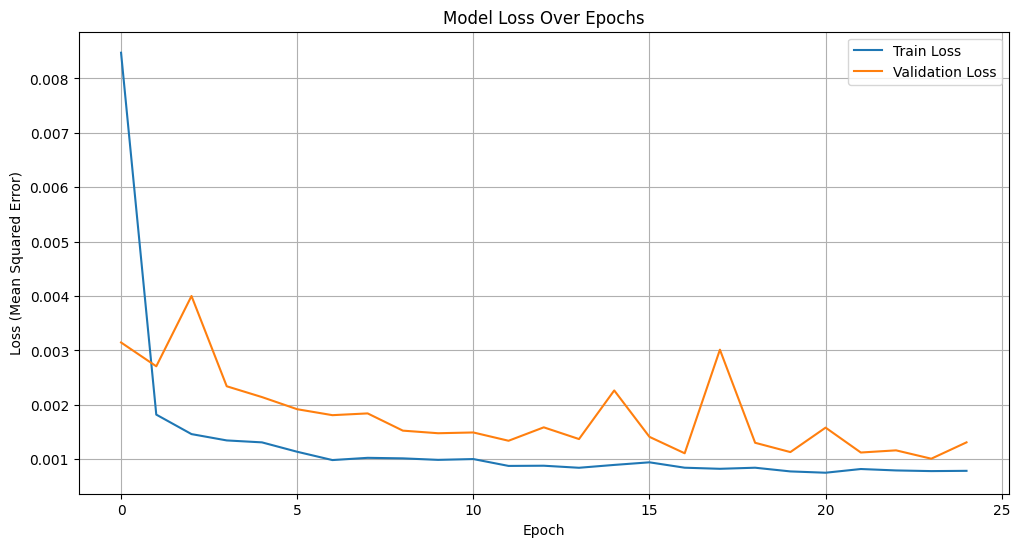

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [11]:
# Combine the last WINDOW_SIZE days of train with all of test, so we have enough history
combined = pd.concat([train[["Close"]].tail(WINDOW_SIZE), test[["Close"]]])
combined_scaled = scaler.transform(combined)

X_test, y_test = create_sequences(combined_scaled, WINDOW_SIZE)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_test shape: {X_test_reshaped.shape}")

# Generate predictions (still in scaled 0-1 form)
predictions_scaled = model_lstm.predict(X_test_reshaped)

# Reverse the scaling to get real dollar values back
predictions = scaler.inverse_transform(predictions_scaled)

print(f"First 5 predictions: {predictions[:5].flatten()}")
print(f"First 5 actual test values: {test['Close'].values[:5]}")

X_test shape: (372, 60, 1)
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step
First 5 predictions: [395.42175 380.33966 374.23532 373.96255 372.99368]
First 5 actual test values: [379.27999878 410.44000244 411.04998779 394.35998535 394.94000244]


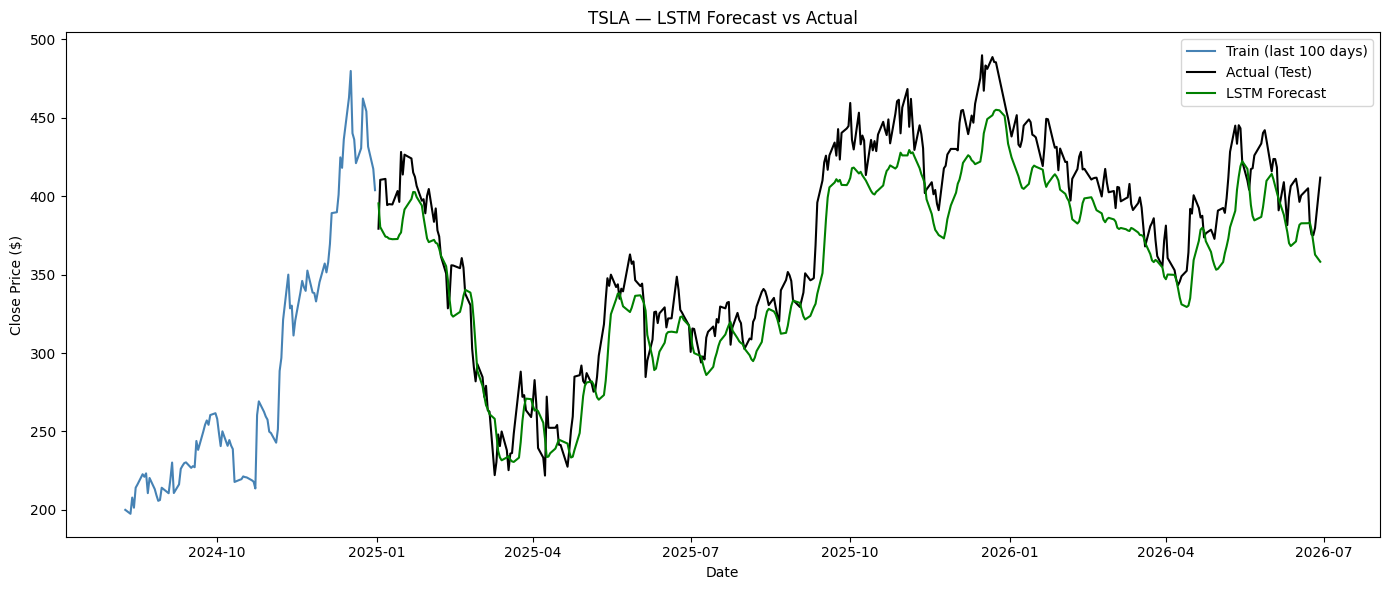

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(train.index[-100:], train["Close"].iloc[-100:], label="Train (last 100 days)", color="steelblue")
plt.plot(test.index, test["Close"], label="Actual (Test)", color="black")
plt.plot(test.index, predictions.flatten(), label="LSTM Forecast", color="green")
plt.title("TSLA — LSTM Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual_lstm = test["Close"].values
predicted_lstm = predictions.flatten()

mae_lstm = mean_absolute_error(actual_lstm, predicted_lstm)
rmse_lstm = np.sqrt(mean_squared_error(actual_lstm, predicted_lstm))
mape_lstm = np.mean(np.abs((actual_lstm - predicted_lstm) / actual_lstm)) * 100

print(f"LSTM Performance on Test Set:")
print(f"  MAE:  ${mae_lstm:.2f}")
print(f"  RMSE: ${rmse_lstm:.2f}")
print(f"  MAPE: {mape_lstm:.2f}%")

LSTM Performance on Test Set:
  MAE:  $20.99
  RMSE: $24.99
  MAPE: 5.55%


## Model Comparison: ARIMA vs. LSTM

| Metric | ARIMA(0,1,0) | LSTM   |
|--------|--------------|--------|
| MAE    | $54.44       | $20.99 |
| RMSE   | $70.54       | $24.99 |
| MAPE   | 17.24%       | 5.55%  |

**Discussion**

LSTM outperformed ARIMA(0,1,0) across all three metrics, reducing error by
roughly 60-68%. Visually, LSTM's forecast actively tracks the shape of
TSLA's actual price movements — including the early-2025 decline and the
late-2025 rally — whereas ARIMA's forecast remained completely flat for
the entire test horizon, since the selected model reduced to a pure random
walk.

This improvement should be interpreted carefully. LSTM's forecasts appear
to lag slightly behind sharp actual price movements, suggesting the model
has learned to closely track recent price levels using its 60-day input
window, rather than genuinely anticipating future direction ahead of time.
Both models are, at their core, leaning heavily on "recent price is the
best predictor of near-future price" — ARIMA freezes this at a single
point, while LSTM continuously updates it using a rolling recent window,
which is why it tracks actual movement far more closely.

This is nonetheless a meaningful practical improvement: a forecast that
updates and roughly follows real price levels is far more useful than one
that is permanently flat. However, neither model demonstrates strong
evidence of anticipating genuine directional turning points *before* they
occur, which is consistent with the Task 1 finding that TSLA's price
behaves close to a random walk and the broader Efficient Market Hypothesis.

In [14]:
# Compare LSTM predictions against actual values shifted by 1 day
# (i.e., "yesterday's actual price" as a naive baseline)
naive_lag = test["Close"].shift(1).values  # yesterday's actual price
lstm_pred = predictions.flatten()

# Drop the first row (NaN from the shift) for a fair comparison
valid_idx = ~np.isnan(naive_lag)

mae_naive_lag = mean_absolute_error(test["Close"].values[valid_idx], naive_lag[valid_idx])
mae_lstm_vs_actual = mean_absolute_error(test["Close"].values[valid_idx], lstm_pred[valid_idx])
mae_lstm_vs_naive_lag = mean_absolute_error(naive_lag[valid_idx], lstm_pred[valid_idx])

print(f"MAE: Naive lag (yesterday's price) vs Actual: ${mae_naive_lag:.2f}")
print(f"MAE: LSTM Forecast vs Actual: ${mae_lstm_vs_actual:.2f}")
print(f"MAE: LSTM Forecast vs Naive Lag (are they similar to each other?): ${mae_lstm_vs_naive_lag:.2f}")

# Correlation check: how closely do LSTM predictions resemble a simple 1-day-lagged actual price?
correlation = np.corrcoef(naive_lag[valid_idx], lstm_pred[valid_idx])[0, 1]
print(f"\nCorrelation between LSTM predictions and naive 1-day lag: {correlation:.4f}")

MAE: Naive lag (yesterday's price) vs Actual: $9.42
MAE: LSTM Forecast vs Actual: $21.00
MAE: LSTM Forecast vs Naive Lag (are they similar to each other?): $19.69

Correlation between LSTM predictions and naive 1-day lag: 0.9849


## Sanity Check: Naive Baseline Comparison

To test whether LSTM's improvement over ARIMA reflects genuine predictive
skill, its forecasts were compared against a naive baseline: simply using
yesterday's actual closing price as today's prediction.

| Approach                          | MAE    |
|-----------------------------------|--------|
| Naive lag (yesterday's price)     | $9.42  |
| LSTM Forecast                     | $21.00 |
| ARIMA(0,1,0)                      | $54.44 |

Surprisingly, the naive lag baseline outperformed both models. Furthermore,
LSTM's predictions showed a 0.9849 correlation with the naive lag baseline,
and the average difference between LSTM and the naive lag ($19.69) was
nearly as large as LSTM's error against actual prices ($21.00). This
indicates that LSTM largely learned to approximate a smoothed version of
"yesterday's price," rather than identifying genuine directional signal
beyond it.

**Conclusion:** While LSTM substantially outperformed ARIMA, neither model
beat the simplest possible naive baseline. This is a strong, concrete
confirmation of the Task 1 finding that TSLA's price behaves close to a
random walk — consistent with the Efficient Market Hypothesis, which
suggests that historical price data alone offers limited ability to
forecast short-term future prices beyond what is already reflected in the
most recent price.